# IMDB Movie Review Sentiment Analysis using ML and DL Models

#1. Import Libraries

In [148]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM,GRU,Dense,Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import re
import string
import nltk
from nltk.corpus import stopwords

#2. Load Dataset

In [5]:
data=pd.read_csv('IMDB Dataset.csv')

In [24]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
data.shape

(50000, 2)

In [7]:
data.isnull().sum()

,0
review,0
sentiment,0


In [8]:
data.dtypes

,0
review,object
sentiment,object


In [9]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [10]:
data_for_ml=data.copy()
data_for_dl=data.copy()

#3. Data Visualization

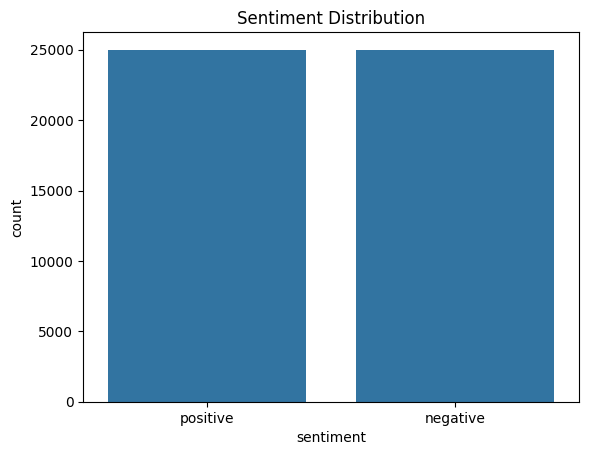

In [11]:
# Visualize sentiment distribution
sns.countplot(x='sentiment', data=data)
plt.title('Sentiment Distribution')
plt.show()

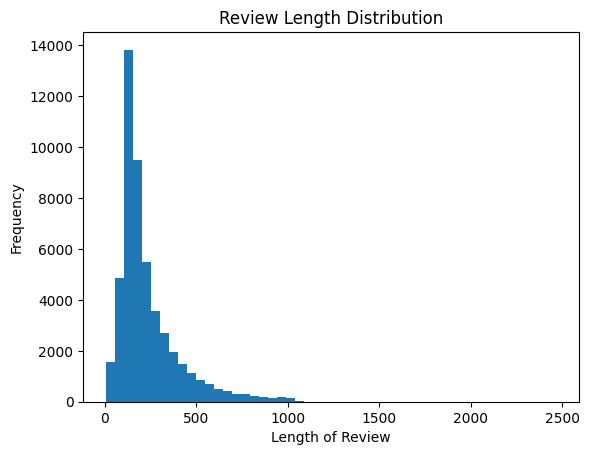

In [12]:
# Review length analysis
review_lengths = data['review'].apply(lambda x: len(x.split()))

plt.hist(review_lengths, bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Length of Review')
plt.ylabel('Frequency')
plt.show()

# 4. Machine Learning Models: Logistic Regression + Naive Bayes (Multinomial and Bernoulli)





#  Data Preprocessing For ML Models











In [13]:
#Encode labels
#positive -----> 1
#negative -----> 0
data_for_ml.replace({'sentiment':{'positive':1,'negative':0}},inplace=True)

In [14]:
data_for_ml.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [15]:
data_for_ml['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


In [16]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()   # convert to lowercase
    text = re.sub(r'<.*?>', '', text)   # remove HTML tags
    text = re.sub(f'[{string.punctuation}]', '', text)   # remove punctuation
    text = re.sub(r'\d+', '', text)   # remove numbers
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [17]:
data_for_ml['review'] = data_for_ml['review'].apply(clean_text)

In [25]:
data_for_ml.head()

,review,sentiment
0,one reviewers mentioned watching oz episode yo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically theres family little boy jake thinks...,0
4,petter matteis love time money visually stunni...,1


#Train-Test Split For ML Models





In [19]:
X = data_for_ml['review']
y = data_for_ml['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(40000,) (10000,) (40000,) (10000,)


In [21]:
X_train.head()

,review
39087,thats kept asking many fights screaming matche...
30893,watch entire movie could watch entire movie st...
45278,touching love story reminiscent in mood love ...
16398,latterday fulci schlocker totally abysmal conc...
13653,first firmly believe norwegian movies continua...


In [22]:
y_train.head()

,sentiment
39087,0
30893,0
45278,1
16398,0
13653,0



#Feature Extraction (TF-IDF) For ML Models
  



In [149]:
# fit_transform on train only — prevents data leakage
# transform on test uses the same vocabulary learned from train

In [23]:
vectorizer = TfidfVectorizer(max_features=10000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#ML Model 1: Logistic Regression

Logistic Regression Model Call

In [26]:
log_model = LogisticRegression()

Logistic Regression Model Train

In [27]:
log_model.fit(X_train_tfidf, y_train)

LogisticRegression()

model evaluation

In [28]:
log_pred = log_model.predict(X_test_tfidf)

Logistic Regression Model Evaluation

In [29]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [30]:
print("Logistic Regression Model Accuracy:", accuracy_score(y_test, log_pred))
print("Logistic Regression Model Precision:", precision_score(y_test, log_pred))
print("Logistic Regression Model Recall:", recall_score(y_test, log_pred))
print("Logistic Regression Model F1 Score:", f1_score(y_test, log_pred))

Logistic Regression Model Accuracy: 0.8924
Logistic Regression Model Precision: 0.8821600771456124
Logistic Regression Model Recall: 0.9077197856717603
Logistic Regression Model F1 Score: 0.8947574334898278


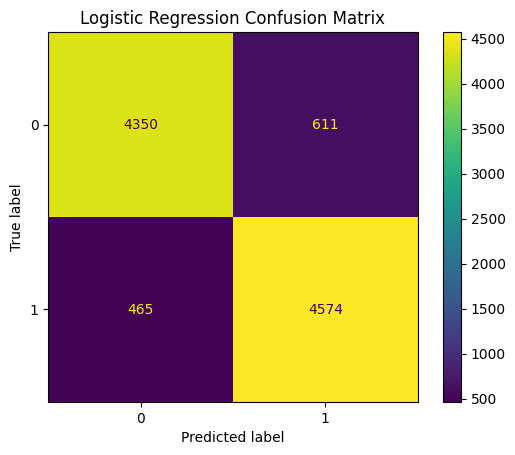

In [31]:
# Confusion Matrix
cm_log = confusion_matrix(y_test, log_pred)
# display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
# plot
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#ML Model 2: Multinomial Naive Bayes

Multinomial Naive Bayes Model Call

In [32]:
nb_model = MultinomialNB()

Multinomial Naive Bayes Model Train

In [33]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

Multinomial Naive Bayes Model Evaluation

In [34]:
nb_pred = nb_model.predict(X_test_tfidf)

In [35]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      4961
           1       0.86      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [36]:
print("Multinomial Naive Bayes Model Accuracy:", accuracy_score(y_test, nb_pred))
print("Multinomial Naive Bayes Model Precision:", precision_score(y_test, nb_pred))
print("Multinomial Naive Bayes Model Recall:", recall_score(y_test, nb_pred))
print("Multinomial Naive Bayes Model F1 Score:", f1_score(y_test, nb_pred))

Multinomial Naive Bayes Model Accuracy: 0.8556
Multinomial Naive Bayes Model Precision: 0.8572848340290201
Multinomial Naive Bayes Model Recall: 0.8559237944036515
Multinomial Naive Bayes Model F1 Score: 0.8566037735849057


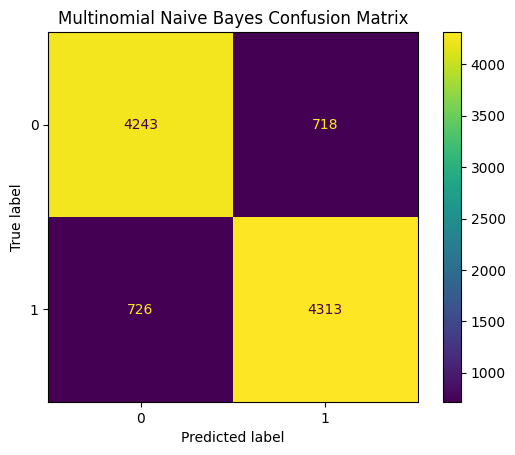

In [37]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred)
# display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
# plot
disp.plot()
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

#ML Model 3: Bernoulli Naive Bayes

Bernoulli Naive Bayes Model Call

In [38]:
bnb_model = BernoulliNB()

Bernoulli Naive Bayes Model Train

In [39]:
bnb_model.fit(X_train_tfidf, y_train)

BernoulliNB()

Bernoulli Naive Bayes Model Evaluation

In [40]:
bnb_pred = bnb_model.predict(X_test_tfidf)

In [41]:
print(classification_report(y_test, bnb_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4961
           1       0.86      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [42]:
print("Bernoulli Naive Bayes Model Accuracy:", accuracy_score(y_test, bnb_pred))
print("Bernoulli Naive Bayes Model Precision:", precision_score(y_test, bnb_pred))
print("Bernoulli Naive Bayes Model Recall:", recall_score(y_test, bnb_pred))
print("Bernoulli Naive Bayes Model F1 Score:", f1_score(y_test, bnb_pred))

Bernoulli Naive Bayes Model Accuracy: 0.8503
Bernoulli Naive Bayes Model Precision: 0.8608394458027709
Bernoulli Naive Bayes Model Recall: 0.8384600119071244
Bernoulli Naive Bayes Model F1 Score: 0.8495023625213632


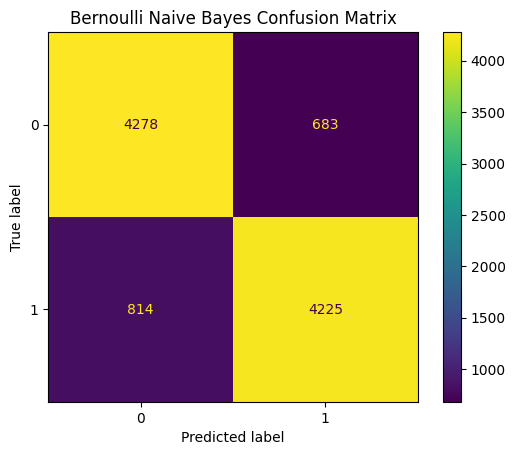

In [43]:
# Confusion Matrix
cm_bnb= confusion_matrix(y_test, bnb_pred)
# display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bnb)
# plot
disp.plot()
plt.title("Bernoulli Naive Bayes Confusion Matrix")
plt.show()

# Machine Learning Models Comparison

In [153]:
print("Machine Learning Models Comparison:\n")
print("Logistic Regression Accuracy :", accuracy_score(y_test, log_pred))
print("Multinomial NB Accuracy :", accuracy_score(y_test, nb_pred))
print("Bernoulli NB Accuracy :", accuracy_score(y_test, bnb_pred))

Machine Learning Models Comparison:

Logistic Regression Accuracy : 0.8924
Multinomial NB Accuracy : 0.8556
Bernoulli NB Accuracy : 0.8503


# 5. Deep Learning Models: RNN, LSTM, GRU

# Data Preprocessing For DL Models

In [45]:
data_for_dl.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [46]:
#Encode labels
#positive -----> 1
#negative -----> 0
data_for_dl.replace({'sentiment':{'positive':1,'negative':0}},inplace=True)

In [47]:
data_for_dl.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [48]:
data_for_dl['review'] = data_for_dl['review'].apply(clean_text)

In [49]:
data_for_dl.head()

,review,sentiment
0,one reviewers mentioned watching oz episode yo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically theres family little boy jake thinks...,0
4,petter matteis love time money visually stunni...,1


# Train-Test Split For DL Models

In [50]:
train_data,test_data=train_test_split(data_for_dl,test_size=0.2,random_state=42)

In [51]:
train_data.shape

(40000, 2)

In [52]:
test_data.shape

(10000, 2)

In [53]:
train_data.head()

,review,sentiment
39087,thats kept asking many fights screaming matche...,0
30893,watch entire movie could watch entire movie st...,0
45278,touching love story reminiscent in mood love ...,1
16398,latterday fulci schlocker totally abysmal conc...,0
13653,first firmly believe norwegian movies continua...,0


#Tokenization For DL Models

In [150]:
# fit_on_texts only on train data — prevents data leakage
# texts_to_sequences on test uses the same vocabulary learned from train

In [54]:
vocab_size = 10000
tokenizer=Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(train_data['review'])

In [55]:
word_index = tokenizer.word_index
print(len(word_index))
list(word_index.items())[:15]

187109


[('movie', 1),
 ('film', 2),
 ('one', 3),
 ('like', 4),
 ('good', 5),
 ('even', 6),
 ('would', 7),
 ('time', 8),
 ('really', 9),
 ('see', 10),
 ('story', 11),
 ('much', 12),
 ('well', 13),
 ('get', 14),
 ('bad', 15)]

In [56]:
sequence = tokenizer.texts_to_sequences(train_data['review'])

In [57]:
for i in range(4):
  print(train_data['review'][i])

one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awayi would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle cla

In [58]:
for i in range(4):
  print(sequence[i])

[84, 643, 1921, 31, 1738, 1820, 4063, 6223, 682, 4932, 127, 5904, 17, 750, 28, 4025, 27, 39, 1018, 2143, 1031, 334, 423, 796, 313, 80, 2883, 4159, 2754, 123, 12, 44, 2928, 140, 108, 4693, 55, 9, 3, 15, 245, 2, 108, 189, 8238, 38, 327, 1499, 506, 299, 267, 20, 40, 36, 268, 356, 6639, 260, 1812, 344, 118, 851, 3964, 83, 2919, 556, 497, 13, 134, 34, 689, 115, 84, 306, 255, 8, 3637, 166, 1526, 94, 597, 1701, 1015, 2819, 3578, 1673, 55, 126, 109, 210, 55, 927, 2437, 8342, 59, 8766, 3860, 1, 885, 396, 145, 14, 31, 31, 565, 9531, 1177, 128, 4064, 106, 993, 3441, 5243, 2168, 321, 511, 584, 2705, 1116, 3317, 80, 1301, 1065, 1411, 719, 1090, 201, 2355, 292, 169, 3318, 842, 1209, 107, 115, 3, 96, 1369, 979, 4547, 130, 237, 4390, 3288, 93, 7949, 1638, 62, 95, 76, 37, 1413, 340, 123, 219, 3047, 1715, 5518, 1187, 2, 3319, 1887, 2233, 344, 409, 2356, 447, 3653, 108, 230, 3606]
[29, 308, 1, 23, 29, 308, 1, 2070, 165, 56, 241, 431, 1252, 145, 408, 56, 465, 523, 3623, 4, 3879, 21, 1476, 669, 1888, 1476,

In [59]:
max_len = 200

In [60]:
X_train_pad=pad_sequences(tokenizer.texts_to_sequences(train_data['review']),maxlen=max_len,padding='pre')
X_test_pad=pad_sequences(tokenizer.texts_to_sequences(test_data['review']),maxlen=max_len,padding='pre')

In [61]:
X_train_pad

array([[   0,    0,    0, ...,  108,  230, 3606],
       [   0,    0,    0, ...,  104,   20,   29],
       [   0,    0,    0, ...,  200,  606,   11],
       ...,
       [   0,    0,    0, ..., 1001, 1469,  514],
       [   0,    0,    0, ...,  142,   29, 6846],
       [   0,    0,    0, ...,  366,   12, 1803]], dtype=int32)

In [62]:
X_test_pad

array([[   0,    0,    0, ...,  169,  100,  845],
       [   0,    0,    0, ..., 1740,   10, 8185],
       [   0,    0,    0, ...,  825,  932,   21],
       ...,
       [   0,    0,    0, ...,  474,   91, 3161],
       [   0,    0,    0, ...,  116,   68, 2072],
       [   0,    0,    0, ...,   10,  229,    3]], dtype=int32)

In [63]:
y_train_dl=train_data['sentiment']
y_test_dl=test_data['sentiment']

In [64]:
y_train_dl.head()

,sentiment
39087,0
30893,0
45278,1
16398,0
13653,0


#DL Model 1 : RNN

Build RNN Model

In [98]:
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=vocab_size, output_dim=256, input_length=max_len))
rnn_model.add(SimpleRNN(units=128))
rnn_model.add(Dropout(0.5))
rnn_model.add(Dense(units=1, activation='sigmoid'))

In [99]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [100]:
rnn_model.build(input_shape=(None,max_len))
rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,409 (9.95 MB)

 Trainable params: 2,609,409 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

Train RNN Model

In [101]:
# train rnn_model
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train_dl,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 267ms/step - accuracy: 0.7617 - loss: 0.5065 - val_accuracy: 0.8296 - val_loss: 0.4042
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 267ms/step - accuracy: 0.6922 - loss: 0.5748 - val_accuracy: 0.6572 - val_loss: 0.6114
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 267ms/step - accuracy: 0.7002 - loss: 0.5723 - val_accuracy: 0.6992 - val_loss: 0.5660
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 265ms/step - accuracy: 0.7819 - loss: 0.4750 - val_accuracy: 0.7857 - val_loss: 0.4682
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 274ms/step - accuracy: 0.7918 - loss: 0.4496 - val_accuracy: 0.7974 - val_loss: 0.4610


RNN Model Training Visualization

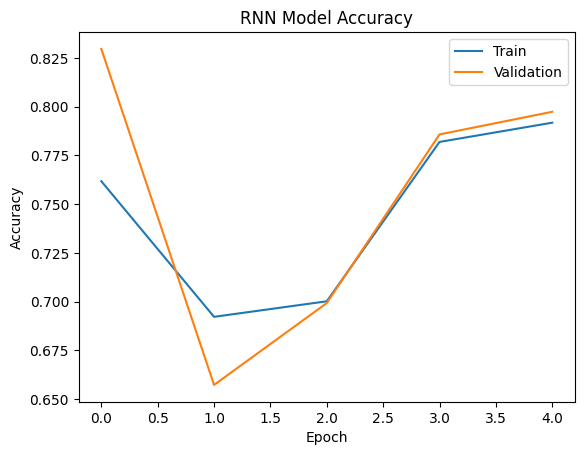

In [102]:
# Accuracy plot
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])
plt.title('RNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

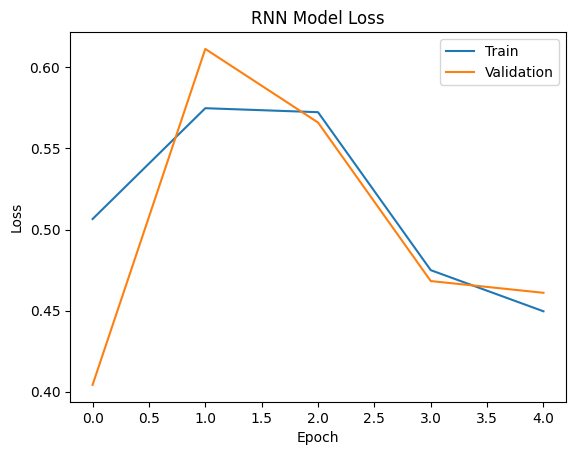

In [103]:
# Loss plot
plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])
plt.title('RNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

RNN Model Evaluation

In [104]:
loss_rnn, accuracy_rnn = rnn_model.evaluate(X_test_pad,y_test_dl)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8011 - loss: 0.4582


In [105]:
y_pred_rnn = rnn_model.predict(X_test_pad)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


In [106]:
y_pred_rnn = (y_pred_rnn> 0.5).astype(int)

In [73]:
print(classification_report(y_test_dl, y_pred_rnn))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      4961
           1       0.87      0.82      0.84      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [107]:
print("RNN Model Accuracy", accuracy_rnn)
print("RNN Model Precision:", precision_score(y_test_dl, y_pred_rnn))
print("RNN Model Recall:", recall_score(y_test_dl, y_pred_rnn))
print("RNN Model F1 Score:", f1_score(y_test_dl, y_pred_rnn))

RNN Model Accuracy 0.8011000156402588
RNN Model Precision: 0.8146925299215848
RNN Model Recall: 0.7834887874578289
RNN Model F1 Score: 0.7987860394537177


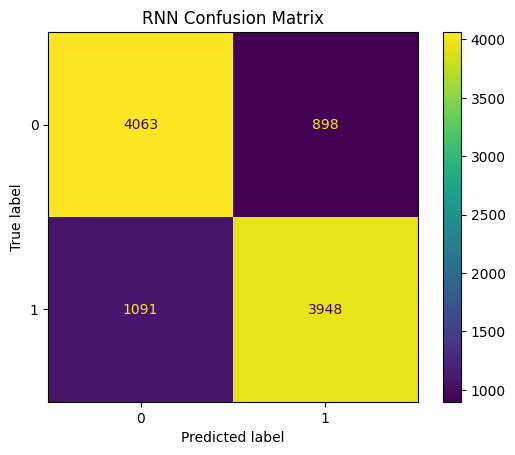

In [108]:
# confusion matrix calculate
cm_rnn = confusion_matrix(y_test_dl, y_pred_rnn)

# display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rnn)

# plot
disp.plot()

plt.title("RNN Confusion Matrix")
plt.show()

# DL Model 2 : LSTM

Build LSTM Model

In [109]:
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=256, input_length=max_len))
lstm_model.add(LSTM(units=128))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(units=1, activation='sigmoid'))

In [66]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [67]:
lstm_model.build(input_shape=(None,max_len))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,757,249 (10.52 MB)

 Trainable params: 2,757,249 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

Train LSTM Model

In [68]:
#EarlyStopping → Stops training when the model is not improving.
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [69]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train_dl,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 411s 816ms/step - accuracy: 0.8237 - loss: 0.3907 - val_accuracy: 0.8618 - val_loss: 0.3424
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 442s 818ms/step - accuracy: 0.9142 - loss: 0.2277 - val_accuracy: 0.8684 - val_loss: 0.3548
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 441s 816ms/step - accuracy: 0.9389 - loss: 0.1641 - val_accuracy: 0.8669 - val_loss: 0.3515
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 410s 820ms/step - accuracy: 0.9581 - loss: 0.1201 - val_accuracy: 0.8540 - val_loss: 0.4152


LSTM Model Training Visualization

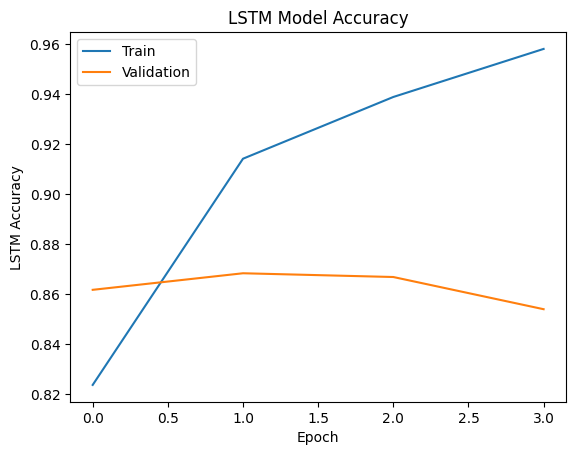

In [70]:
# Accuracy plot
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('LSTM Model Accuracy')
plt.ylabel('LSTM Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

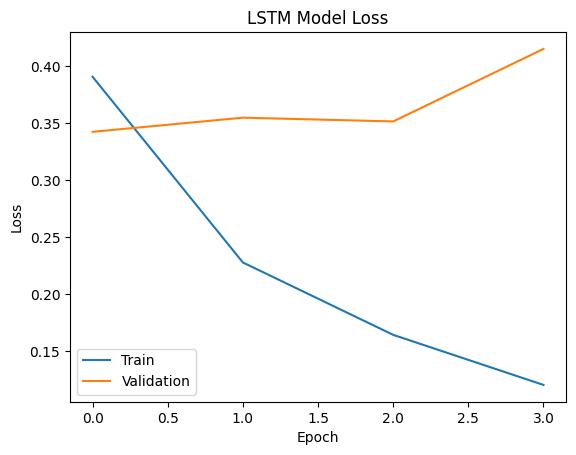

In [151]:
# Loss plot
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

LSTM Model Evaluation

In [71]:
loss_lstm, accuracy_lstm = lstm_model.evaluate(X_test_pad,y_test_dl)

313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 145ms/step - accuracy: 0.8712 - loss: 0.3228


In [72]:
y_pred_lstm = lstm_model.predict(X_test_pad)

313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step


In [73]:
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

In [74]:
y_pred_lstm

array([[0],
       [1],
       [0],
       ...,
       [1],
       [0],
       [1]])

In [75]:
print(classification_report(y_test_dl, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      4961
           1       0.91      0.82      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [76]:
print("LSTM Model Accuracy", accuracy_lstm)
print("LSTM Model Precision:", precision_score(y_test_dl, y_pred_lstm))
print("LSTM Model Recall:", recall_score(y_test_dl, y_pred_lstm))
print("LSTM Model F1 Score:", f1_score(y_test_dl, y_pred_lstm))

LSTM Model Accuracy 0.8712000250816345
LSTM Model Precision: 0.9122884150362717
LSTM Model Recall: 0.8235761063703115
LSTM Model F1 Score: 0.8656654151022111


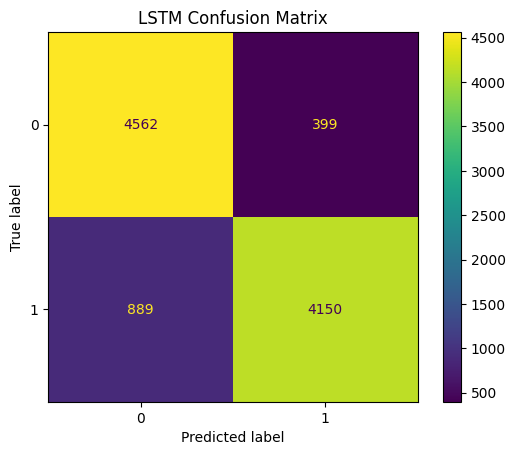

In [77]:
# confusion matrix calculate
cm_lstm = confusion_matrix(y_test_dl, y_pred_lstm)

# display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm)

# plot
disp.plot()

plt.title("LSTM Confusion Matrix")
plt.show()

# DL Model 3 : GRU

Build GRU Model

In [78]:
gru_model = Sequential()
gru_model.add(Embedding(input_dim=vocab_size, output_dim=256, input_length=max_len))
gru_model.add(GRU(units=128))
gru_model.add(Dropout(0.5))
gru_model.add(Dense(units=1, activation='sigmoid'))

In [79]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [80]:
gru_model.build(input_shape=(None,max_len))
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,708,353 (10.33 MB)

 Trainable params: 2,708,353 (10.33 MB)

 Non-trainable params: 0 (0.00 B)

Train GRU Model

In [81]:
# train gru_model
history_gru = gru_model.fit(
    X_train_pad,
    y_train_dl,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 417s 826ms/step - accuracy: 0.8290 - loss: 0.3812 - val_accuracy: 0.8750 - val_loss: 0.3030
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 413s 768ms/step - accuracy: 0.9141 - loss: 0.2244 - val_accuracy: 0.8806 - val_loss: 0.2995
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 435s 870ms/step - accuracy: 0.9424 - loss: 0.1518 - val_accuracy: 0.8755 - val_loss: 0.3374
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 378s 741ms/step - accuracy: 0.9661 - loss: 0.0981 - val_accuracy: 0.8630 - val_loss: 0.4065
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 358s 717ms/step - accuracy: 0.9789 - loss: 0.0642 - val_accuracy: 0.8602 - val_loss: 0.4920


GRU Model Training Visualization

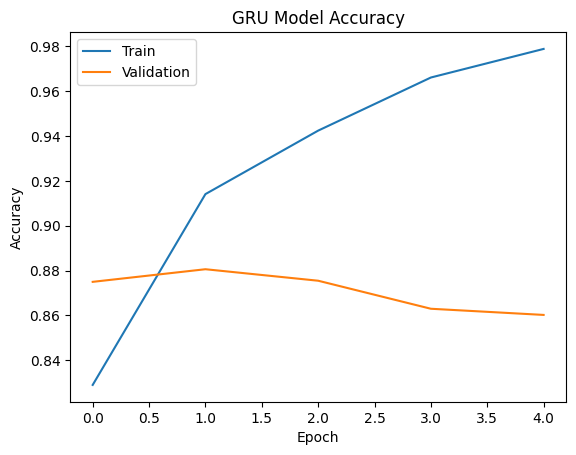

In [82]:
# Accuracy plot
plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('GRU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

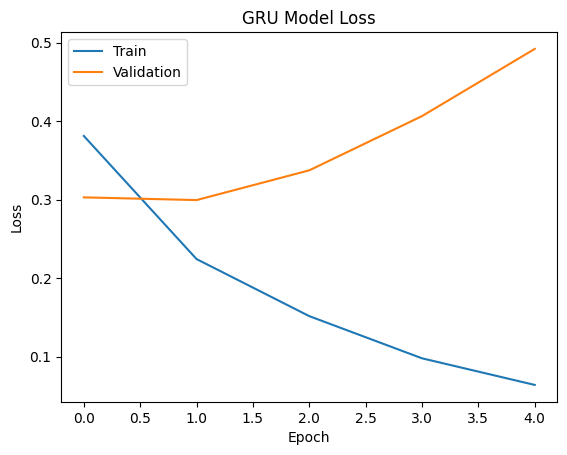

In [83]:
# Loss plot
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('GRU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

GRU Model Evaluation

In [84]:
loss_gru, accuracy_gru = gru_model.evaluate(X_test_pad,y_test_dl)

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.8833 - loss: 0.2874


In [85]:
y_pred_gru = gru_model.predict(X_test_pad)

313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step


In [86]:
y_pred_gru = (y_pred_gru > 0.5).astype(int)

In [87]:
print(classification_report(y_test_dl, y_pred_gru))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      4961
           1       0.89      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [88]:
print("GRU Model Accuracy", accuracy_gru)
print("GRU Model Precision:", precision_score(y_test_dl, y_pred_gru))
print("GRU Model Recall:", recall_score(y_test_dl, y_pred_gru))
print("GRU Model F1 Score:", f1_score(y_test_dl, y_pred_gru))

GRU Model Accuracy 0.8833000063896179
GRU Model Precision: 0.8907953169156237
GRU Model Recall: 0.8757690017860686
GRU Model F1 Score: 0.8832182527769439


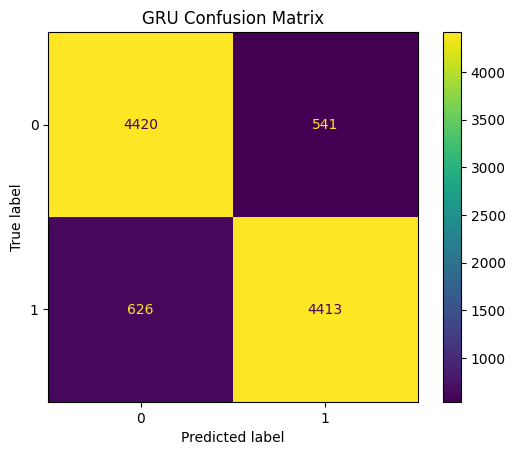

In [89]:
# confusion matrix calculate
cm_gru = confusion_matrix(y_test_dl, y_pred_gru)

# display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gru)

# plot
disp.plot()

plt.title("GRU Confusion Matrix")
plt.show()

# Deep Learning Models Comparison

In [110]:
print("Deep Learning Models Comparison:\n")
print("RNN Model Accuracy:", accuracy_rnn)
print("LSTM Model Accuracy:", accuracy_lstm)
print("GRU Model Accuracy:", accuracy_gru)

Deep Learning Models Comparison:

RNN Model Accuracy: 0.8011000156402588
LSTM Model Accuracy: 0.8712000250816345
GRU Model Accuracy: 0.8833000063896179


# 6. Machine Learning Models and Deep Learning Models Comparison

In [152]:
print("Machine Learning Models and Deep Learning Models Comparison:\n")
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Multinomial NB Accuracy:", accuracy_score(y_test, nb_pred))
print("Bernoulli NB Accuracy:", accuracy_score(y_test, bnb_pred))
print("RNN Model Accuracy:", accuracy_rnn)
print("LSTM Model Accuracy:", accuracy_lstm)
print("GRU Model Accuracy:", accuracy_gru)

Machine Learning Models and Deep Learning Models Comparison:

Logistic Regression Accuracy: 0.8924
Multinomial NB Accuracy: 0.8556
Bernoulli NB Accuracy: 0.8503
RNN Model Accuracy: 0.8011000156402588
LSTM Model Accuracy: 0.8712000250816345
GRU Model Accuracy: 0.8833000063896179


#7. Saving the Best Two Models

 Best ML model: Logistic Regression

In [127]:
import joblib
joblib.dump(log_model, 'logistic_regression_model.joblib')

['logistic_regression_model.joblib']

Best Deep Learning model: GRU

In [128]:
gru_model.save('GRU_model.h5')

#8. Prediction Function

In [130]:
# Load ML model
loaded_ml_model = joblib.load('logistic_regression_model.joblib')

In [131]:
# Load DL model
from tensorflow.keras.models import load_model

loaded_gru_model = load_model('GRU_model.h5')

In [138]:
def predict_sentiment_logistic_regression_model(review):
    review = clean_text(review)
    vector = vectorizer.transform([review])
    prediction = loaded_ml_model.predict(vector)
    return "Positive" if prediction[0] == 1 else "Negative"

In [139]:
predict_sentiment_logistic_regression_model('movie boring')

'Negative'

In [140]:
predict_sentiment_logistic_regression_model('The movie has a very nice story')

'Positive'

In [142]:
predict_sentiment_logistic_regression_model('This movie is enjoyable, but the visualization is poor. However, everybody will like it.')

'Negative'

In [144]:
def predict_sentiment_gru_model(review):
    review = clean_text(review)
    sequence = tokenizer.texts_to_sequences([review])
    padded_sequence = pad_sequences(sequence, maxlen=200)
    prediction = loaded_gru_model.predict(padded_sequence)
    sentiment = "positive" if prediction > 0.5 else "negative"
    return sentiment

In [145]:
predict_sentiment_gru_model('movie boring')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


'negative'

In [146]:
predict_sentiment_gru_model('The movie has a very nice story')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


'positive'

In [147]:
predict_sentiment_gru_model('This movie is enjoyable, but the visualization is poor. However, everybody will like it.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


'positive'